# 08 Customer Segmentation

## Objective
Identify meaningful customer groups using sales behavior, with all logic in this notebook.

## Segmentation Features
- total_spending
- purchase_frequency

In [1]:
from pathlib import Path
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans

candidate_roots = [Path.cwd(), Path.cwd().parent]
project_root = next((p for p in candidate_roots if (p / 'data').exists()), None)
if project_root is None:
    raise FileNotFoundError('Could not locate data folder. Run from project root or notebooks folder.')

data_dir = project_root / 'data'
print(f'Project Root: {project_root}')
print(f'Data Directory: {data_dir}')

Project Root: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai
Data Directory: D:\projects\ai-ml-projects\PharmaEase_correct\pharma_ease_ai\data


In [2]:
sales = pd.read_csv(data_dir / 'sales.csv')
sales['date'] = pd.to_datetime(sales['date'], errors='coerce')
sales['revenue'] = sales['quantity'] * sales['price']

customer_features = sales.groupby('customer_id', as_index=False).agg(
    total_spending=('revenue', 'sum'),
    purchase_frequency=('transaction_id', 'count')
)

print(f'Customer feature table shape: {customer_features.shape}')
display(customer_features.head())

Customer feature table shape: (1127, 3)


,customer_id,total_spending,purchase_frequency
0,CUST-1000,69.05,1
1,CUST-1001,24.30,1
2,CUST-1002,68.04,1
3,CUST-1003,153.02,1
4,CUST-1004,43.20,1


In [3]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features['segment'] = kmeans.fit_predict(
    customer_features[['total_spending', 'purchase_frequency']]
)

medians = customer_features[['total_spending', 'purchase_frequency']].median()
segment_labels = {}
for i, (spend, freq) in enumerate(kmeans.cluster_centers_):
    if spend > medians['total_spending'] and freq > medians['purchase_frequency']:
        segment_labels[i] = 'VIP: High Spend and High Frequency'
    elif spend > medians['total_spending']:
        segment_labels[i] = 'Premium: High Spend'
    elif freq > medians['purchase_frequency']:
        segment_labels[i] = 'Loyal: High Frequency'
    else:
        segment_labels[i] = 'Standard: Low Spend and Frequency'

customer_features['segment_label'] = customer_features['segment'].map(segment_labels)

print('Segment counts:')
print(customer_features['segment_label'].value_counts())

Segment counts:
segment_label
Standard: Low Spend and Frequency     465
Premium: High Spend                   377
VIP: High Spend and High Frequency    285
Name: count, dtype: int64


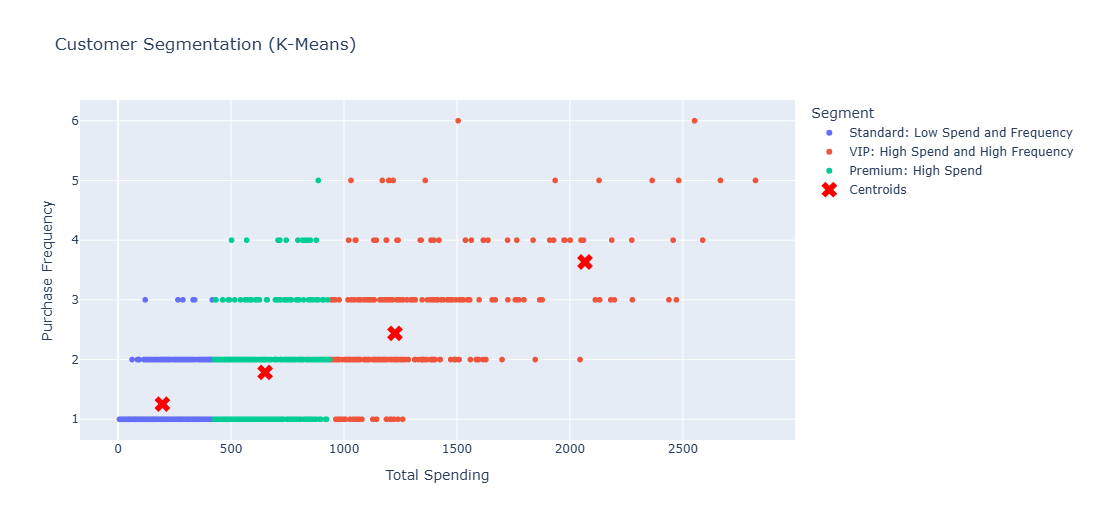

In [4]:
fig = px.scatter(
    customer_features,
    x='total_spending',
    y='purchase_frequency',
    color='segment_label',
    title='Customer Segmentation (K-Means)',
    labels={
        'total_spending': 'Total Spending',
        'purchase_frequency': 'Purchase Frequency',
        'segment_label': 'Segment'
    }
)
fig.add_scatter(
    x=kmeans.cluster_centers_[:, 0],
    y=kmeans.cluster_centers_[:, 1],
    mode='markers',
    marker=dict(size=14, color='red', symbol='x'),
    name='Centroids'
)
fig.update_layout(height=520)
fig.show()

In [5]:
print('\nSegment Insights:')
print('=' * 70)
for seg in customer_features['segment_label'].unique():
    seg_df = customer_features[customer_features['segment_label'] == seg]
    print(f'\n{seg}')
    print(f'  Count: {len(seg_df)}')
    print(f'  Avg Spending: {seg_df["total_spending"].mean():.2f}')
    print(f'  Avg Frequency: {seg_df["purchase_frequency"].mean():.2f}')


Segment Insights:

Standard: Low Spend and Frequency
  Count: 465
  Avg Spending: 196.30
  Avg Frequency: 1.25

VIP: High Spend and High Frequency
  Count: 285
  Avg Spending: 1346.57
  Avg Frequency: 2.61

Premium: High Spend
  Count: 377
  Avg Spending: 650.86
  Avg Frequency: 1.79


## Segment Strategy

- **VIP**: retain with premium offers and concierge support.
- **Premium**: increase frequency through loyalty bundles.
- **Loyal**: increase basket size with cross-sell promotions.
- **Standard**: activate with targeted discounts and education campaigns.